# 07 — A5000 Video Inference Profiling (Stage 2)

**Purpose:** Profile inference latency and throughput on video input,
targeting real-time deployment requirements for the EcoCAR vehicle.

**Metrics:**
- Per-frame latency (ms) — model + NMS + lane postprocessing
- Throughput (FPS) at batch=1 and batch=N
- GPU memory usage
- Qualitative video overlay output

**Close-vehicle box cleanup:** The video overlay now runs class-agnostic NMS and a second-stage fragment cleanup before tracking/drawing. This is intended to prevent one nearby vehicle from being visualized as several duplicate boxes.


In [2]:
import os, sys
os.chdir('/content')
from google.colab import drive
drive.mount('/content/drive')
!pip install -q yacs tqdm opencv-python-headless

import os, sys
REPO_ROOT = '/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane'
os.chdir(REPO_ROOT)
sys.path.insert(0, REPO_ROOT)

Mounted at /content/drive


In [3]:

import torch
import cv2
import numpy as np
import time
import json
from lib.config import cfg
from lib.models import get_net
from lib.core.general import non_max_suppression, scale_coords
from lib.utils import show_seg_result, plot_one_box, letterbox_for_img
from lib.utils.video_box_cleanup import cleanup_vehicle_detections

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')


Device: cuda
GPU: NVIDIA L4
GPU Memory: 22.0 GB


In [4]:
# ── Load model ──
# Stage1 default profiling target = YOLOPX. Fail loudly if the YOLOPX
# checkpoint is missing — never silently profile the older YOLOP model.
CONFIG = 'YOLOPX'
CHECKPOINT_NAME = 'best_joint.pth'

yaml_map = {
    'YOLOPX':             os.path.join(REPO_ROOT, 'stage1', 'configs', 'yolopx_vehicle_lane_baseline.yaml'),
    'YOLOP':              os.path.join(REPO_ROOT, 'stage1', 'configs', 'yolop_vehicle_lane_baseline.yaml'),
    'YOLOPv2-paper-no-da': os.path.join(REPO_ROOT, 'stage1', 'configs', 'yolopv2_paper_no_da.yaml'),
    'YOLOPv2-best-row':   os.path.join(REPO_ROOT, 'stage1', 'configs', 'yolopv2_best_row.yaml'),
    'YOLOPv2-focal-only': os.path.join(REPO_ROOT, 'stage1', 'configs', 'yolopv2_focal_only_ablation.yaml'),
}
run_name_map = {
    'YOLOPX':             'yolopx',
    'YOLOP':              'yolop',
    'YOLOPv2-paper-no-da': 'yolopv2_paper_no_da',
    'YOLOPv2-best-row':   'yolopv2_best_row',
    'YOLOPv2-focal-only': 'yolopv2_focal_only',
}

assert CONFIG in yaml_map, f'Unknown CONFIG={CONFIG}. Valid: {list(yaml_map)}'
yaml_path = yaml_map[CONFIG]
assert os.path.exists(yaml_path), f'Missing config YAML: {yaml_path}'

cfg.defrost()
cfg.merge_from_file(yaml_path)
run_name = run_name_map[CONFIG]
cfg.DRIVE.CHECKPOINT_DIR = os.path.join(REPO_ROOT, 'stage1', 'checkpoints', run_name)
cfg.DRIVE.METRICS_DIR = os.path.join(REPO_ROOT, 'stage1', 'metrics', run_name)
os.makedirs(cfg.DRIVE.METRICS_DIR, exist_ok=True)
cfg.freeze()

checkpoint_candidates = [
    os.path.join(cfg.DRIVE.CHECKPOINT_DIR, CHECKPOINT_NAME),
    os.path.join(cfg.DRIVE.CHECKPOINT_DIR, 'best_joint.pth'),
    os.path.join(cfg.DRIVE.CHECKPOINT_DIR, 'best.pth'),
    os.path.join(cfg.DRIVE.CHECKPOINT_DIR, 'latest.pth'),
]
ckpt_path = next((p for p in checkpoint_candidates if os.path.exists(p)), None)
if ckpt_path is None:
    raise FileNotFoundError(
        f'No {CONFIG} checkpoint found in {cfg.DRIVE.CHECKPOINT_DIR}.\n'
        f'Tried: {checkpoint_candidates}\n'
        f'Run notebook 02 first to produce a YOLOPX checkpoint.'
    )

model = get_net(cfg).to(device)
model.gr = 1.0
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt['state_dict'])
model.eval()
use_fp16 = torch.cuda.is_available()
if use_fp16:
    model.half()
num_params = sum(p.numel() for p in model.parameters())

print('=' * 64)
print('[Stage1 / 07 video-profile preflight]')
print(f'  Model family    : {CONFIG}')
print(f'  Model.NAME      : {cfg.MODEL.NAME}')
print(f'  Config YAML     : {yaml_path}')
print(f'  Checkpoint dir  : {cfg.DRIVE.CHECKPOINT_DIR}')
print(f'  Checkpoint file : {ckpt_path}')
print(f'  Metrics dir     : {cfg.DRIVE.METRICS_DIR}')
print(f'  epoch={ckpt.get("epoch", "?")} params={num_params/1e6:.2f} M  nc={model.nc}')
print(f'  FP16            : {use_fp16}')
print('=' * 64)

def predict_lane_prob(m, x):
    if hasattr(m, 'predict'):
        return m.predict(x)
    det_out, lane_raw = m(x)
    if lane_raw.shape[1] == 2:
        if lane_raw.detach().min() >= 0 and lane_raw.detach().max() <= 1:
            lane_prob = lane_raw[:, 1:2]
        else:
            lane_prob = torch.softmax(lane_raw, dim=1)[:, 1:2]
    else:
        if lane_raw.detach().min() >= 0 and lane_raw.detach().max() <= 1:
            lane_prob = lane_raw[:, :1]
        else:
            lane_prob = torch.sigmoid(lane_raw[:, :1])
    return det_out, lane_prob

with torch.no_grad():
    z = torch.zeros(1, 3, 640, 640, device=device, dtype=torch.float16 if use_fp16 else torch.float32)
    _det, lane_logits = model(z)
    _det_p, lane_prob = predict_lane_prob(model, z)
print(f'forward() lane shape : {tuple(lane_logits.shape)}')
print(f'predict lane shape   : {tuple(lane_prob.shape)}')


[Stage1 / 07 video-profile preflight]
  Model family    : YOLOPX
  Model.NAME      : YOLOPX
  Config YAML     : /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage1/configs/yolopx_vehicle_lane_baseline.yaml
  Checkpoint dir  : /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage1/checkpoints/yolopx
  Checkpoint file : /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage1/checkpoints/yolopx/best_joint.pth
  Metrics dir     : /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage1/metrics/yolopx
  epoch=87 params=31.38 M  nc=1
  FP16            : True
forward() lane shape : (1, 2, 640, 640)
predict lane shape   : (1, 1, 640, 640)


In [5]:

# ── Latency benchmark (synthetic input, stage-1 eval resolution) ──
TARGET_WH = tuple(getattr(cfg.TEST, 'IMAGE_SIZE', [640, 384]))
TARGET_HW = (int(TARGET_WH[1]), int(TARGET_WH[0]))
INPUT_H, INPUT_W = TARGET_HW

warmup_iters = 30
bench_iters = 100

dtype = torch.float16 if use_fp16 else torch.float32
dummy = torch.randn(1, 3, INPUT_H, INPUT_W, device=device, dtype=dtype)

for _ in range(warmup_iters):
    with torch.no_grad():
        _ = model(dummy)
if torch.cuda.is_available():
    torch.cuda.synchronize()

latencies = []
for _ in range(bench_iters):
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = model(dummy)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    latencies.append((time.perf_counter() - t0) * 1000)

latencies = np.array(latencies)
print(f'Latency (batch=1, input={INPUT_W}x{INPUT_H}):')
print(f'  Mean:   {latencies.mean():.2f} ms')
print(f'  Median: {np.median(latencies):.2f} ms')
print(f'  P95:    {np.percentile(latencies, 95):.2f} ms')
print(f'  P99:    {np.percentile(latencies, 99):.2f} ms')
print(f'  Uncapped model FPS: {1000 / latencies.mean():.1f}')
if torch.cuda.is_available():
    print(f'  GPU Mem: {torch.cuda.max_memory_allocated() / 1024**2:.0f} MB')


Latency (batch=1, input=640x384):
  Mean:   21.81 ms
  Median: 21.59 ms
  P95:    22.70 ms
  P99:    26.44 ms
  Uncapped model FPS: 45.9
  GPU Mem: 523 MB


## Model FLOPs Utilization (MFU)

MFU measures how efficiently the model saturates the GPU's compute throughput:

```
MFU = achieved_FLOPs/sec  /  peak_FLOPs/sec
    = (FLOPs_per_forward × batch_size / latency_sec) / peak_TFLOPS
```

**Target GPU: NVIDIA RTX A5000** (24 GB, GA102, Ampere Tensor Cores).

| precision | peak TFLOPS (dense) | peak TFLOPS (sparse) |
|---|---:|---:|
| FP32           |  27.8 |  — |
| TF32           |  55.6 | 111.1 |
| FP16 / BF16    | 111.1 | 222.2 |
| INT8           | 222.2 | 444.3 |

Source: NVIDIA RTX A5000 datasheet. The MFU cell below uses the **dense FP16 = 111.1 TFLOPS** number, which is the honest upper bound for this workload in PyTorch without structured sparsity.

**Interpretation:**
- **< 10 %**: memory-bound or kernel-launch-dominated (small batch, elementwise-heavy).
- **10–30 %**: typical for real-time detection at batch=1 on Ampere.
- **30–60 %**: compute-bound regime.
- **> 60 %**: near-peak, rare for multi-task networks.

In [6]:
# ── FLOP counting (one-time analysis) ──
# FLOPs are precision-independent, so we count on an FP32 copy even though
# the benchmark model runs in FP16. thop counts MACs — we multiply by 2 for FLOPs.
!pip install -q thop

import copy
from thop import profile as thop_profile

fp32_model = copy.deepcopy(model).float().eval()
dummy_fp32 = torch.randn(1, 3, 640, 640, device=device)

with torch.no_grad():
    macs, params = thop_profile(fp32_model, inputs=(dummy_fp32,), verbose=False)

FLOPS_PER_FORWARD = 2 * macs  # 1 MAC = 2 FLOPs
GFLOPS_PER_FORWARD = FLOPS_PER_FORWARD / 1e9

print(f'Parameters:              {params/1e6:.2f} M')
print(f'MACs per forward:        {macs/1e9:.2f} G')
print(f'FLOPs per forward:       {GFLOPS_PER_FORWARD:.2f} GFLOPs  (640×640, batch=1)')
print(f'FLOPs per pixel:         {FLOPS_PER_FORWARD / (640*640):.1f}')

del fp32_model, dummy_fp32
torch.cuda.empty_cache()

Parameters:              31.38 M
MACs per forward:        69.10 G
FLOPs per forward:       138.21 GFLOPs  (640×640, batch=1)
FLOPs per pixel:         337424.0



RTX A5000  |  peak FP16 tensor = 111.1 TFLOPS  |  model = 138.21 GFLOPs/forward

 Batch    Lat(ms)       FPS     TFLOPS    MFU %    Mem(MB)
---------------------------------------------------------
     1      22.71      44.0       6.09    5.48%        532
     2      22.23      90.0      12.44   11.19%        612
     4      34.95     114.5      15.82   14.24%        778
     8      74.86     106.9      14.77   13.29%       1110
    16     166.59      96.0      13.27   11.95%       1774
    32     350.79      91.2      12.61   11.35%       3102


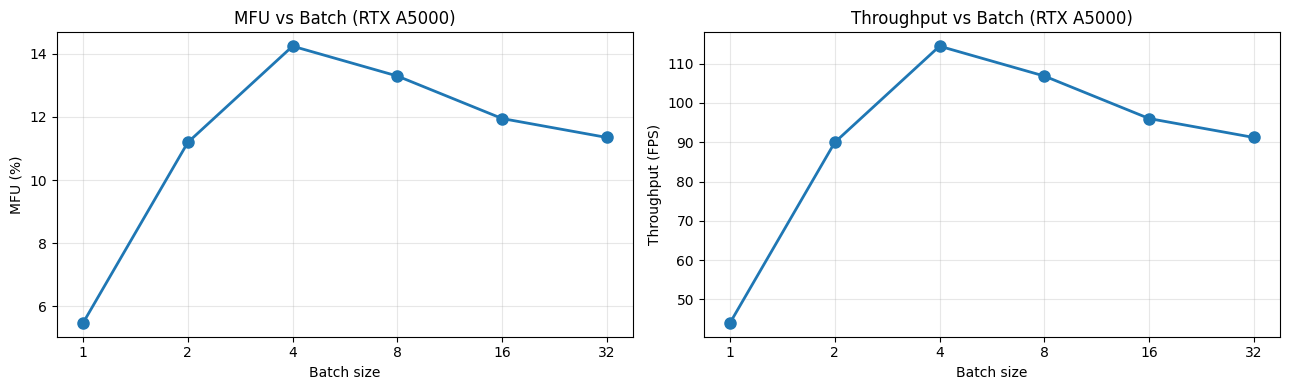

Saved MFU sweep to /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage1/metrics/yolopx/a5000_profile


In [7]:

# ── MFU sweep across batch sizes ──
import json
import matplotlib.pyplot as plt

GPU_NAME = 'RTX A5000'
PEAK_TFLOPS = 111.1
PEAK_FLOPS_PER_SEC = PEAK_TFLOPS * 1e12

dtype = torch.float16 if use_fp16 else torch.float32
BATCH_SIZES = [1, 2, 4, 8, 16, 32]
WARMUP = 20
ITERS = 60

results = []
for bs in BATCH_SIZES:
    try:
        x = torch.randn(bs, 3, 640, 640, device=device, dtype=dtype)

        for _ in range(WARMUP):
            with torch.no_grad():
                _ = model(x)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
            torch.cuda.reset_peak_memory_stats()

        lats = []
        for _ in range(ITERS):
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            with torch.no_grad():
                _ = model(x)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            lats.append(time.perf_counter() - t0)

        lat_s = float(np.median(lats))
        achieved_flops = (FLOPS_PER_FORWARD * bs) / lat_s
        achieved_tflops = achieved_flops / 1e12
        mfu = achieved_flops / PEAK_FLOPS_PER_SEC
        fps = bs / lat_s
        mem_mb = (torch.cuda.max_memory_allocated() / 1024**2) if torch.cuda.is_available() else 0.0

        results.append({
            'batch': bs,
            'latency_ms': lat_s * 1000,
            'throughput_fps': fps,
            'achieved_tflops': achieved_tflops,
            'mfu_pct': mfu * 100,
            'peak_mem_mb': mem_mb,
        })
        del x
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except torch.cuda.OutOfMemoryError:
        print(f'OOM at batch={bs} - stopping sweep')
        torch.cuda.empty_cache()
        break

print(f'\n{GPU_NAME}  |  peak FP16 tensor = {PEAK_TFLOPS:.1f} TFLOPS  |  model = {GFLOPS_PER_FORWARD:.2f} GFLOPs/forward')
print(f'\n{"Batch":>6} {"Lat(ms)":>10} {"FPS":>9} {"TFLOPS":>10} {"MFU %":>8} {"Mem(MB)":>10}')
print('-' * 57)
for r in results:
    print(f'{r["batch"]:>6} {r["latency_ms"]:>10.2f} {r["throughput_fps"]:>9.1f} '
          f'{r["achieved_tflops"]:>10.2f} {r["mfu_pct"]:>7.2f}% {r["peak_mem_mb"]:>10.0f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
bs_arr = [r['batch'] for r in results]
mfu_arr = [r['mfu_pct'] for r in results]
fps_arr = [r['throughput_fps'] for r in results]

ax1.plot(bs_arr, mfu_arr, 'o-', linewidth=2, markersize=8)
ax1.set_xlabel('Batch size')
ax1.set_ylabel('MFU (%)')
ax1.set_title(f'MFU vs Batch ({GPU_NAME})')
ax1.set_xscale('log', base=2)
ax1.set_xticks(bs_arr)
ax1.set_xticklabels(bs_arr)
ax1.grid(alpha=0.3)

ax2.plot(bs_arr, fps_arr, 'o-', linewidth=2, markersize=8)
ax2.set_xlabel('Batch size')
ax2.set_ylabel('Throughput (FPS)')
ax2.set_title(f'Throughput vs Batch ({GPU_NAME})')
ax2.set_xscale('log', base=2)
ax2.set_xticks(bs_arr)
ax2.set_xticklabels(bs_arr)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

report_dir = os.path.join(cfg.DRIVE.METRICS_DIR, 'a5000_profile')
os.makedirs(report_dir, exist_ok=True)
with open(os.path.join(report_dir, f'{CONFIG.lower()}_mfu_sweep.json'), 'w') as f:
    json.dump(results, f, indent=2)
print(f'Saved MFU sweep to {report_dir}')


In [8]:

# ── Video inference demo (stable colors + correct lane de-letterbox + measured FPS) ──
# Close vehicles can create several overlapping class-specific boxes. The video
# profiler therefore uses class-agnostic NMS plus a second-stage fragment cleanup
# before tracking and drawing.
VIDEO_PATH = '/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/video/input.mp4'
VIDEO_OUT_DIR = os.path.join(cfg.DRIVE.METRICS_DIR, 'a5000_profile')
os.makedirs(VIDEO_OUT_DIR, exist_ok=True)

CONF_THRES = 0.25
CONF_SWEEP = [0.25, 0.10, 0.05, 0.02, 0.01, 0.005]
IOU_THRES = 0.35
NMS_AGNOSTIC = True
TRACK_IOU = 0.45
TRACK_MAX_AGE = 8
TRACK_MIN_HITS = 2
SMOOTH_ALPHA = 0.45
TARGET_WH = tuple(getattr(cfg.TEST, 'IMAGE_SIZE', [640, 384]))
TARGET_HW = (int(TARGET_WH[1]), int(TARGET_WH[0]))
WRITE_VIDEO = True
WRITER_FPS_MODE = 'measured'   # 'source' or 'measured'
MAX_FRAMES = 30000
DRAW_RAW_DETECTIONS_WHEN_NO_TRACK = True
MIN_BOX_AREA = 120
ENABLE_CLOSE_VEHICLE_CLEANUP = True
CLOSE_OBJECT_AREA_RATIO = 0.025
FRAGMENT_CONTAINMENT_THRES = 0.58
FRAGMENT_CENTER_INTER_THRES = 0.20
FRAGMENT_CONF_MARGIN = 0.20
FRAGMENT_SAME_OBJECT_IOU = 0.72
PREFLIGHT_FRAMES = 10
adaptive_conf_usage = {}


def _prediction_score_debug(inf_out):
    stats = {'shape': list(inf_out.shape)}
    t = inf_out.detach().float()
    stats['tensor_min'] = float(t.min().cpu()) if t.numel() else None
    stats['tensor_max'] = float(t.max().cpu()) if t.numel() else None
    if t.ndim == 3 and t.shape[-1] >= 6:
        stats['max_obj_col4'] = float(t[..., 4].max().cpu())
        stats['max_cls_after5'] = float(t[..., 5:].max().cpu())
        stats['max_obj_times_cls'] = float((t[..., 4:5] * t[..., 5:]).max().cpu())
    return stats


def _adaptive_nms(inf_out, thresholds, iou_thres, agnostic):
    last = None
    for conf in thresholds:
        out = non_max_suppression(inf_out, conf_thres=float(conf), iou_thres=iou_thres, agnostic=agnostic)
        last = out
        if len(out) and len(out[0]):
            adaptive_conf_usage[float(conf)] = adaptive_conf_usage.get(float(conf), 0) + 1
            return out, float(conf)
    adaptive_conf_usage[float(thresholds[-1])] = adaptive_conf_usage.get(float(thresholds[-1]), 0) + 1
    return last, float(thresholds[-1])


def _run_detection_preflight(video_path, frames_to_check=10):
    if not os.path.exists(video_path):
        print(f'[preflight] video not found: {video_path}')
        return
    cap_pf = cv2.VideoCapture(video_path)
    checked = 0
    threshold_counts = {float(x): 0 for x in CONF_SWEEP}
    print('\nDetection preflight:')
    while checked < frames_to_check:
        ret, frame = cap_pf.read()
        if not ret:
            break
        img_lb, ratio, (dw, dh) = letterbox_for_img(frame, new_shape=TARGET_HW, auto=False)
        img_t = torch.from_numpy(img_lb[:, :, ::-1].copy()).permute(2, 0, 1).unsqueeze(0)
        img_t = img_t.to(device=device, dtype=dtype) / 255.0
        with torch.no_grad():
            inf_out, _lane_prob = _decode_video_outputs(model, img_t)
        stats = _prediction_score_debug(inf_out)
        per_thr = {}
        for conf in CONF_SWEEP:
            out = non_max_suppression(inf_out, conf_thres=float(conf), iou_thres=IOU_THRES, agnostic=NMS_AGNOSTIC)
            count = int(len(out[0])) if len(out) else 0
            per_thr[float(conf)] = count
            if count > 0:
                threshold_counts[float(conf)] += 1
        print(f'[preflight] frame={checked} stats={stats} nms_counts={per_thr}', flush=True)
        checked += 1
    cap_pf.release()
    print(f'[preflight] frames_checked={checked} threshold_hit_frames={threshold_counts}', flush=True)
    if checked > 0 and sum(threshold_counts.values()) == 0:
        print('[preflight][WARNING] NMS produced zero boxes at every threshold. The output video will be lane-only unless the checkpoint detection branch or YOLOPX decode format is fixed.', flush=True)
    else:
        print('[preflight] detection branch produced boxes at least once; video drawing should show boxes unless filters remove them.', flush=True)


def _xyxy_iou(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter = inter_w * inter_h
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    return inter / max(area_a + area_b - inter, 1e-6)


def _track_color(track_id):
    palette = [
        (255, 99, 71), (135, 206, 235), (50, 205, 50),
        (255, 215, 0), (186, 85, 211), (255, 140, 0),
        (64, 224, 208), (220, 20, 60), (70, 130, 180),
    ]
    return palette[track_id % len(palette)]


def _remove_letterbox_from_mask(mask, input_hw, dw, dh, out_hw):
    in_h, in_w = input_hw
    out_h, out_w = mask.shape[:2]
    sx = out_w / float(in_w)
    sy = out_h / float(in_h)
    pad_left = int(round(dw * sx))
    pad_right = int(round(dw * sx))
    pad_top = int(round(dh * sy))
    pad_bottom = int(round(dh * sy))

    x1 = max(0, pad_left)
    x2 = max(x1 + 1, out_w - pad_right)
    y1 = max(0, pad_top)
    y2 = max(y1 + 1, out_h - pad_bottom)
    crop = mask[y1:y2, x1:x2]
    return cv2.resize(crop, (out_hw[1], out_hw[0]), interpolation=cv2.INTER_NEAREST)


def _unpack_inference_prediction(det_out):
    if isinstance(det_out, (list, tuple)):
        first = det_out[0]
        if torch.is_tensor(first) and first.ndim == 3:
            return first
        if isinstance(first, (list, tuple)) and len(first) and torch.is_tensor(first[0]) and first[0].ndim == 3:
            return first[0]
    if torch.is_tensor(det_out) and det_out.ndim == 3:
        return det_out
    raise RuntimeError(f'Cannot unpack detection output for NMS. Type={type(det_out)}')


def _decode_video_outputs(model, img_t):
    if hasattr(model, 'predict'):
        det_out, lane_prob = model.predict(img_t)
        inf_out = _unpack_inference_prediction(det_out)
        return inf_out, lane_prob
    det_out, lane_raw = model(img_t)
    inf_out = _unpack_inference_prediction(det_out)
    if lane_raw.shape[1] == 2:
        lane_prob = torch.softmax(lane_raw, dim=1)[:, 1:2]
    else:
        lane_prob = torch.sigmoid(lane_raw[:, :1])
    return inf_out, lane_prob


tracks = []
next_track_id = 0

if os.path.exists(VIDEO_PATH):
    cap = cv2.VideoCapture(VIDEO_PATH)
    src_fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f'Video: {w}x{h} @ {src_fps}fps, {total} frames')
    dtype = torch.float16 if use_fp16 else torch.float32

    _run_detection_preflight(VIDEO_PATH, frames_to_check=PREFLIGHT_FRAMES)

    frame_times = []
    raw_det_count = 0
    used_conf_sum = 0.0
    kept_det_count = 0
    cleanup_input_count = 0
    cleanup_output_count = 0
    cleanup_suppressed_count = 0
    drawn_box_count = 0
    frames = [] if WRITE_VIDEO else None
    max_frames = min(total, MAX_FRAMES)

    for fi in range(max_frames):
        ret, frame = cap.read()
        if not ret:
            break
        vis = frame.copy()

        img_lb, ratio, (dw, dh) = letterbox_for_img(frame, new_shape=TARGET_HW, auto=False)
        img_t = torch.from_numpy(img_lb[:, :, ::-1].copy()).permute(2, 0, 1).unsqueeze(0)
        img_t = img_t.to(device=device, dtype=dtype) / 255.0

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.no_grad():
            inf_out, lane_prob = _decode_video_outputs(model, img_t)
            output, used_conf = _adaptive_nms(inf_out, CONF_SWEEP, IOU_THRES, NMS_AGNOSTIC)
            used_conf_sum += float(used_conf)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        frame_times.append((time.perf_counter() - t0) * 1000)

        # Lane overlay: remove letterbox padding BEFORE resizing back to original frame.
        ll_mask = (lane_prob[0, 0] > 0.5).cpu().numpy().astype(np.uint8)
        ll_mask_orig = _remove_letterbox_from_mask(ll_mask, TARGET_HW, dw, dh, (h, w))
        vis[ll_mask_orig > 0] = vis[ll_mask_orig > 0] * 0.55 + np.array([0, 255, 0]) * 0.45

        detections = []
        raw_det_count += int(len(output[0]))
        if len(output[0]):
            det = output[0].cpu()
            det[:, :4] = scale_coords(img_lb.shape[:2], det[:, :4], vis.shape, ratio_pad=((ratio[0], ratio[1]), (dw, dh))).round()
            for *xyxy, conf, cls in det.tolist():
                x1, y1, x2, y2 = xyxy
                area = max(0.0, x2 - x1) * max(0.0, y2 - y1)
                if area < MIN_BOX_AREA:
                    continue
                detections.append({'bbox': [x1, y1, x2, y2], 'conf': conf, 'cls': int(cls)})
        kept_det_count += len(detections)

        if ENABLE_CLOSE_VEHICLE_CLEANUP and detections:
            detections, cleanup_stats = cleanup_vehicle_detections(
                detections,
                image_shape=vis.shape[:2],
                close_object_area_ratio=CLOSE_OBJECT_AREA_RATIO,
                containment_threshold=FRAGMENT_CONTAINMENT_THRES,
                center_inside_inter_threshold=FRAGMENT_CENTER_INTER_THRES,
                confidence_margin=FRAGMENT_CONF_MARGIN,
                same_object_iou_threshold=FRAGMENT_SAME_OBJECT_IOU,
                min_box_area=MIN_BOX_AREA,
            )
            cleanup_input_count += cleanup_stats['input']
            cleanup_output_count += cleanup_stats['output']
            cleanup_suppressed_count += cleanup_stats['suppressed_fragments']
        else:
            cleanup_input_count += len(detections)
            cleanup_output_count += len(detections)

        for tr in tracks:
            tr['age'] += 1

        matched_tracks = set()
        for det in sorted(detections, key=lambda d: d['conf'], reverse=True):
            best_iou = 0.0
            best_idx = -1
            for ti, tr in enumerate(tracks):
                if ti in matched_tracks or tr['cls'] != det['cls']:
                    continue
                iou = _xyxy_iou(tr['bbox'], det['bbox'])
                if iou > best_iou:
                    best_iou = iou
                    best_idx = ti
            if best_idx >= 0 and best_iou >= TRACK_IOU:
                tr = tracks[best_idx]
                old = np.array(tr['bbox'], dtype=np.float32)
                new = np.array(det['bbox'], dtype=np.float32)
                tr['bbox'] = (SMOOTH_ALPHA * new + (1.0 - SMOOTH_ALPHA) * old).tolist()
                tr['conf'] = det['conf']
                tr['age'] = 0
                tr['hits'] += 1
                matched_tracks.add(best_idx)
            else:
                tracks.append({'id': next_track_id, 'bbox': det['bbox'], 'conf': det['conf'], 'cls': det['cls'], 'age': 0, 'hits': 1})
                next_track_id += 1

        tracks = [tr for tr in tracks if tr['age'] <= TRACK_MAX_AGE]

        drawn_this_frame = 0
        for tr in tracks:
            if tr['hits'] < TRACK_MIN_HITS:
                continue
            x1, y1, x2, y2 = tr['bbox']
            color = _track_color(tr['id'])
            name = cfg.MODEL.VEHICLE_CLASSES[min(tr['cls'], len(cfg.MODEL.VEHICLE_CLASSES) - 1)]
            label = f'{name} id={tr["id"]} {tr["conf"]:.2f}'
            plot_one_box([x1, y1, x2, y2], vis, color=color, label=label, line_thickness=2)
            drawn_this_frame += 1
        if DRAW_RAW_DETECTIONS_WHEN_NO_TRACK and drawn_this_frame == 0:
            for det in detections:
                x1, y1, x2, y2 = det['bbox']
                name = cfg.MODEL.VEHICLE_CLASSES[min(det['cls'], len(cfg.MODEL.VEHICLE_CLASSES) - 1)]
                label = f'{name} raw {det["conf"]:.2f}'
                plot_one_box([x1, y1, x2, y2], vis, color=(255, 128, 0), label=label, line_thickness=2)
                drawn_this_frame += 1
        drawn_box_count += drawn_this_frame

        if WRITE_VIDEO:
            frames.append(vis.astype(np.uint8))

    cap.release()

    frame_times = np.array(frame_times)
    measured_fps = float(1000.0 / frame_times.mean()) if len(frame_times) else 0.0
    writer_fps = measured_fps if WRITER_FPS_MODE == 'measured' else src_fps

    out_path = None
    if WRITE_VIDEO and frames:
        out_path = os.path.join(VIDEO_OUT_DIR, f'{CONFIG.lower()}_inference_output.mp4')
        writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), writer_fps, (w, h))
        for fr in frames:
            writer.write(fr)
        writer.release()

    video_summary = {
        'config': CONFIG,
        'checkpoint': ckpt_path,
        'frames_processed': int(len(frame_times)),
        'mean_latency_ms': float(frame_times.mean()) if len(frame_times) else None,
        'median_latency_ms': float(np.median(frame_times)) if len(frame_times) else None,
        'uncapped_pipeline_fps': measured_fps,
        'source_video_fps': float(src_fps),
        'writer_fps': float(writer_fps),
        'conf_thres_primary': CONF_THRES,
        'conf_sweep': CONF_SWEEP,
        'adaptive_conf_usage': {str(k): int(v) for k, v in adaptive_conf_usage.items()},
        'mean_used_conf_thres': float(used_conf_sum / max(len(frame_times), 1)),
        'track_iou': TRACK_IOU,
        'nms_agnostic': bool(NMS_AGNOSTIC),
        'close_vehicle_cleanup': bool(ENABLE_CLOSE_VEHICLE_CLEANUP),
        'close_object_area_ratio': CLOSE_OBJECT_AREA_RATIO,
        'fragment_containment_threshold': FRAGMENT_CONTAINMENT_THRES,
        'output_video': out_path,
        'raw_nms_detections': int(raw_det_count),
        'kept_after_area_filter': int(kept_det_count),
        'cleanup_input_boxes': int(cleanup_input_count),
        'cleanup_output_boxes': int(cleanup_output_count),
        'cleanup_suppressed_fragments': int(cleanup_suppressed_count),
        'drawn_boxes': int(drawn_box_count),
    }
    print('\nVideo inference summary:')
    print(json.dumps(video_summary, indent=2))
    if video_summary['raw_nms_detections'] == 0 or video_summary['drawn_boxes'] == 0:
        print('WARNING: no usable detection boxes were drawn. The preflight table above tells whether this is a threshold problem or a detection-output/decode/checkpoint problem.', flush=True)
    with open(os.path.join(VIDEO_OUT_DIR, f'{CONFIG.lower()}_video_profile.json'), 'w') as f:
        json.dump(video_summary, f, indent=2)
    if out_path is not None:
        print(f'Output saved to {out_path}')
else:
    print(f'No test video found at {VIDEO_PATH}. Skipping video demo.')


Video: 1920x1080 @ 30.0fps, 2829 frames

Detection preflight:
[preflight] frame=0 stats={'shape': [1, 5040, 6], 'tensor_min': -1.2626953125, 'tensor_max': 637.5, 'max_obj_col4': 0.93896484375, 'max_cls_after5': 0.255126953125, 'max_obj_times_cls': 0.2341700792312622} nms_counts={0.25: 0, 0.1: 4, 0.05: 7, 0.01: 75}
[preflight] frame=1 stats={'shape': [1, 5040, 6], 'tensor_min': -1.8125, 'tensor_max': 637.5, 'max_obj_col4': 0.9306640625, 'max_cls_after5': 0.254150390625, 'max_obj_times_cls': 0.22982585430145264} nms_counts={0.25: 0, 0.1: 4, 0.05: 5, 0.01: 81}
[preflight] frame=2 stats={'shape': [1, 5040, 6], 'tensor_min': 2.8848648071289062e-05, 'tensor_max': 638.5, 'max_obj_col4': 0.9189453125, 'max_cls_after5': 0.253662109375, 'max_obj_times_cls': 0.22794151306152344} nms_counts={0.25: 0, 0.1: 4, 0.05: 7, 0.01: 76}
[preflight] frame=3 stats={'shape': [1, 5040, 6], 'tensor_min': 2.8192996978759766e-05, 'tensor_max': 638.5, 'max_obj_col4': 0.9189453125, 'max_cls_after5': 0.253662109375, 